In [8]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, brier_score_loss
import shap
import joblib

In [2]:
df = pd.read_csv('../Data/HRDataset_v14.csv')
df['Position'] = df['Position'].str.strip()
df = df.dropna(subset=['ManagerID'])

In [5]:
# High perfprmer flag (binary because too few entries)
df['High_Performer'] = df['PerformanceScore'].isin(['Fully Meets', 'Exceeds']).astype(int)

perf_features = [
    'Absences', 
    'EngagementSurvey', 'EmpSatisfaction', 'DeptID'
]

X_perf = pd.get_dummies(df[perf_features], drop_first=True)
y_perf = df['High_Performer']

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

brier_scorer = make_scorer(brier_score_loss, response_method='predict_proba', greater_is_better=False)

scoring = {
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'brier': brier_scorer
}

perf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=0))
])

cv_results = cross_validate(perf_pipeline, X_perf, y_perf, cv=rkf, scoring=scoring, n_jobs=-1)

print(f"--- Performance Model Results (Mean ± Std) ---")
print(f"ROC-AUC: {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}")
print(f"F1-Score: {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}")
print(f"Brier Score: {-cv_results['test_brier'].mean():.3f} ± {cv_results['test_brier'].std():.3f}")

--- Performance Model Results (Mean ± Std) ---
ROC-AUC: 0.894 ± 0.093
F1-Score: 0.978 ± 0.012
Brier Score: 0.036 ± 0.015


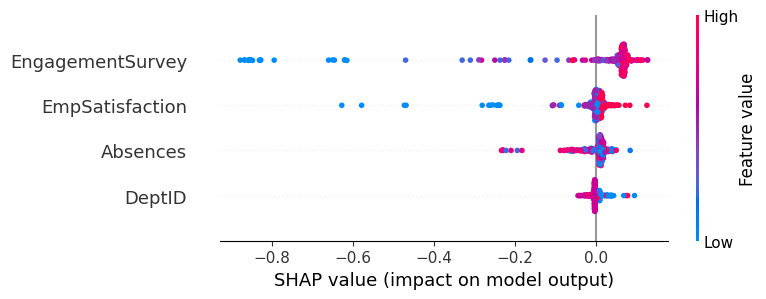

In [ ]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=0)
rf_model.fit(X_perf, y_perf)
explainer = shap.Explainer(rf_model, X_perf)
shap_values = explainer(X_perf)
shap.summary_plot(shap_values.values[:, :, 1], X_perf)

In [9]:
save_path = '../Saved models/performance_driver_analysis.pkl'
joblib.dump(perf_pipeline, save_path)

['../Saved models/performance_driver_analysis.pkl']